# Bivariate Analysis with Target Variable

Objective:
- Understand relationships between features and the target (`crime_type`)
- Identify predictive signals and weak features
- Detect leakage risks or post-outcome variables

Rules:
- No feature transformations
- No model training
- No target-aware cleaning
- Analysis only, decisions documented


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [ ]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
data_path = os.path.join(project_root, 'data', 'interim', 'cleaned_data.csv')

crime_data = pd.read_csv(data_path)
crime_data.head()

(10000, 10)

In [6]:
TARGET_COL = "crime_type"

assert TARGET_COL in crime_data.columns, "Target column missing"


In [8]:
#Separate feature types (re-confirm)
numeric_cols = crime_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = crime_data.select_dtypes(include=["object"]).columns.tolist()

if TARGET_COL in numeric_cols:
	numeric_cols.remove(TARGET_COL)
if TARGET_COL in categorical_cols:
	categorical_cols.remove(TARGET_COL)

numeric_cols, categorical_cols


(['crime_id',
  'latitude',
  'longitude',
  'hour',
  'victim_age',
  'suspect_age',
  'arrest_made'],
 ['day_of_week', 'weapon_used'])

In [9]:
crime_data[TARGET_COL].value_counts(normalize=True)


crime_type
Fraud        0.1464
Burglary     0.1439
Homicide     0.1429
Assault      0.1428
Vandalism    0.1426
Theft        0.1423
Robbery      0.1391
Name: proportion, dtype: float64

In [11]:
# Numeric features vs target (aggregated)

for col in numeric_cols:
    display(
        crime_data.groupby(TARGET_COL)[col]
        .mean()
        .sort_values(ascending=False)
    )


crime_type
Assault      5107.285014
Homicide     5088.584325
Vandalism    5001.105189
Fraud        4997.644809
Robbery      4995.158879
Burglary     4934.391244
Theft        4879.288124
Name: crime_id, dtype: float64

crime_type
Homicide     1.280340
Theft        0.874708
Burglary     0.750806
Robbery      0.178194
Vandalism   -0.147191
Fraud       -0.315495
Assault     -1.451910
Name: latitude, dtype: float64

crime_type
Vandalism    7.108408
Assault      2.830560
Burglary     0.097651
Theft       -1.386271
Fraud       -2.886900
Robbery     -3.553512
Homicide    -5.773886
Name: longitude, dtype: float64

crime_type
Assault      11.819328
Homicide     11.795661
Fraud        11.668716
Robbery      11.638390
Theft        11.597330
Burglary     11.495483
Vandalism    11.222300
Name: hour, dtype: float64

crime_type
Theft        44.579058
Homicide     44.498950
Fraud        44.449454
Burglary     44.372481
Robbery      44.312725
Vandalism    44.311360
Assault      43.854342
Name: victim_age, dtype: float64

crime_type
Robbery      42.868440
Fraud        42.427596
Vandalism    42.289621
Homicide     42.081875
Burglary     41.985407
Assault      41.859944
Theft        41.778637
Name: suspect_age, dtype: float64

crime_type
Burglary     0.312717
Robbery      0.312006
Vandalism    0.307854
Assault      0.299020
Homicide     0.296011
Theft        0.293043
Fraud        0.282787
Name: arrest_made, dtype: float64

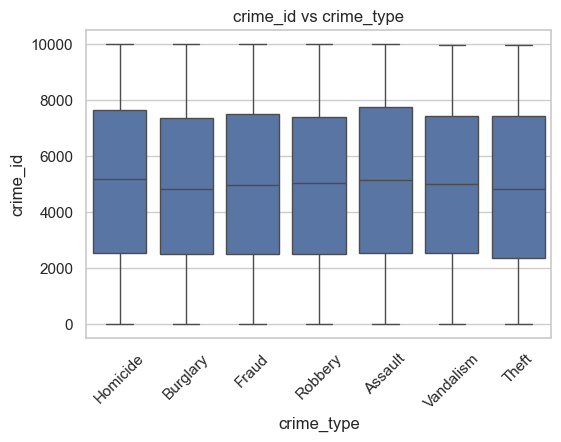

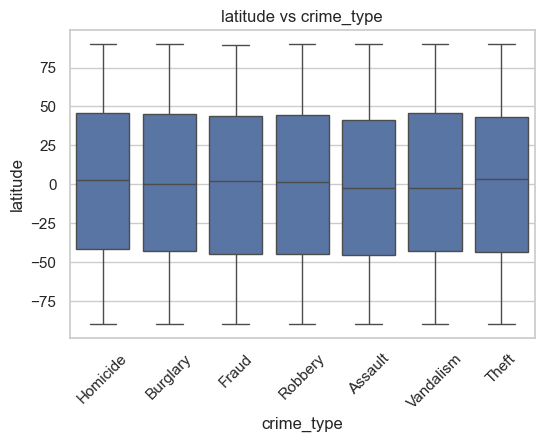

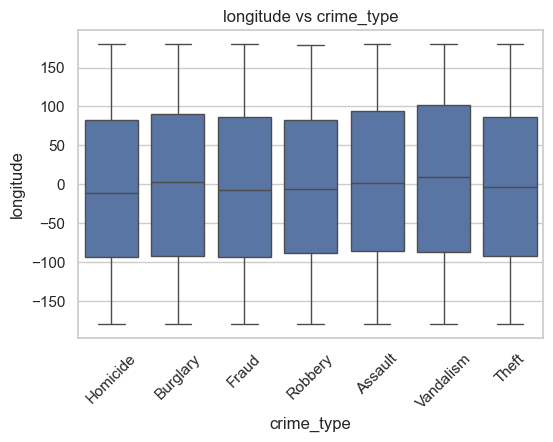

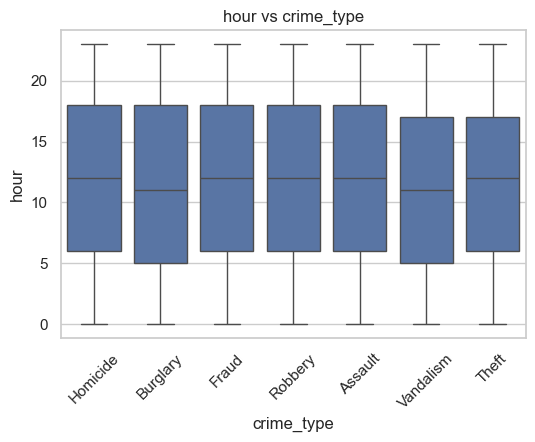

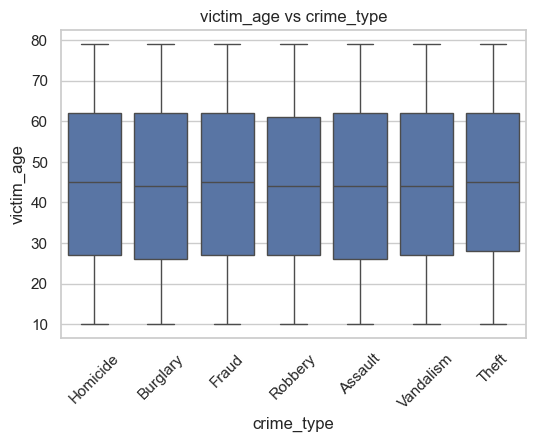

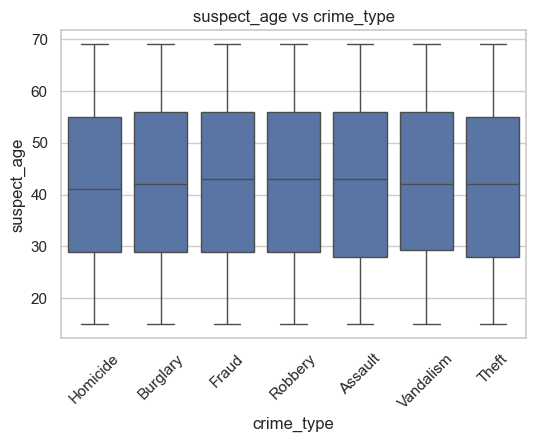

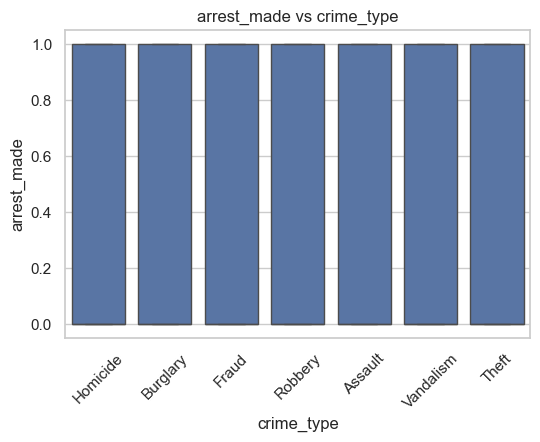

In [ ]:
# Numeric vs target (boxplots)

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=crime_data, x=TARGET_COL, y=col)
    plt.title(f"{col} vs {TARGET_COL}")
    plt.xticks(rotation=45)
    plt.show()


In [13]:
# Categorical features vs target (cross-tabulations)

for col in categorical_cols:
    ct = pd.crosstab(crime_data[col], crime_data[TARGET_COL], normalize="index")
    display(ct)


crime_type,Assault,Burglary,Fraud,Homicide,Robbery,Theft,Vandalism
day_of_week,,,,,,,
Fri,0.154282,0.137297,0.140835,0.129512,0.138004,0.150743,0.149328
Mon,0.143279,0.146233,0.155096,0.138848,0.123338,0.153619,0.139586
Sat,0.139518,0.145184,0.142351,0.131020,0.145892,0.139518,0.156516
Sun,0.131377,0.143256,0.158630,0.153739,0.147449,0.134172,0.131377
Thu,0.153741,0.157823,0.135374,0.141497,0.132653,0.136735,0.142177
Tue,0.144547,0.134691,0.146518,0.164258,0.141919,0.144547,0.123522
Wed,0.132332,0.143062,0.146638,0.139485,0.143777,0.137339,0.157368


crime_type,Assault,Burglary,Fraud,Homicide,Robbery,Theft,Vandalism
weapon_used,,,,,,,
blunt object,0.148903,0.146944,0.146552,0.132837,0.138715,0.141850,0.144201
gun,0.133197,0.138525,0.153279,0.141803,0.141803,0.147131,0.144262
knife,0.146467,0.144887,0.145677,0.151204,0.129491,0.143308,0.138966
unknown,0.142222,0.145051,0.140202,0.145859,0.146667,0.136970,0.143030


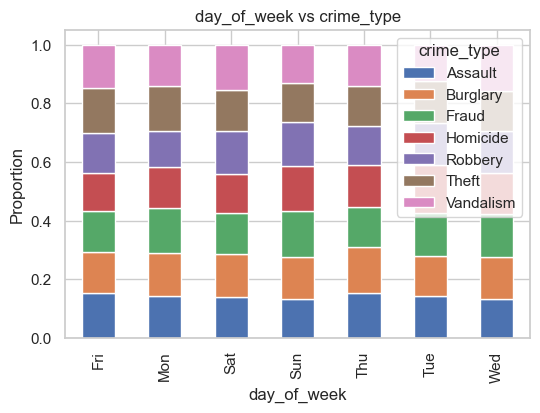

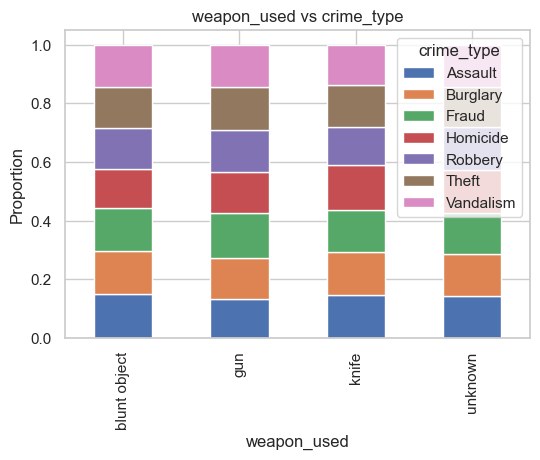

In [14]:
# Categorical vs target (bar plots)

for col in categorical_cols:
    ct = pd.crosstab(crime_data[col], crime_data[TARGET_COL], normalize="index")
    ct.plot(kind="bar", stacked=True, figsize=(6, 4))
    plt.title(f"{col} vs {TARGET_COL}")
    plt.ylabel("Proportion")
    plt.show()


In [15]:
# Example cross-tabulation for a specific categorical feature

pd.crosstab(
    crime_data["weapon_used"],
    crime_data[TARGET_COL],
    normalize="index"
)


crime_type,Assault,Burglary,Fraud,Homicide,Robbery,Theft,Vandalism
weapon_used,,,,,,,
blunt object,0.148903,0.146944,0.146552,0.132837,0.138715,0.141850,0.144201
gun,0.133197,0.138525,0.153279,0.141803,0.141803,0.147131,0.144262
knife,0.146467,0.144887,0.145677,0.151204,0.129491,0.143308,0.138966
unknown,0.142222,0.145051,0.140202,0.145859,0.146667,0.136970,0.143030


## Feature–Target Observations

Strong signals:
- weapon_used
- hour (temporal patterns)

Moderate signals:
- day_of_week
- location bins (to be engineered)

Weak / unclear:
- Raw latitude/longitude (need transformation)


## Leakage Risk Review

- No features appear deterministically derived from `crime_type`
- No post-outcome fields detected
- Temporal features are safe
- `weapon_used` is observed at event time

Status: No obvious leakage detected


## Decisions from Bivariate Analysis

- Retain all features for feature engineering
- Transform numeric features later
- Encode categorical features with care
- Preserve `"unknown"` as meaningful category
